# Базовая резервируемая система Росса

Сохранены параметры примера: десять рабочих машин, три холодных резервных,
один ремонтник, средние времена отказа и ремонта 100 и 1 час, пять прогонов.

In [1]:
using DrWatson
@quickactivate "EventSystemsStudy"
ENV["GKSwstype"] = "100"
include(srcdir("EventSystemsStudy.jl"))
using .EventSystemsStudy.RepairReserve, .EventSystemsStudy.EvidenceIO
using DataFrames, Statistics, Plots

## Пять воспроизводимых прогонов

In [2]:
runs = NamedTuple[]
traces = DataFrame[]
for run in 1:5
    result = run_reserve(required=10, spares=3, repairers=1,
        failure_mean=100.0, repair_mean=1.0, seed=149+run)
    push!(runs, merge((run=run,), result.summary))
    push!(traces, result.trace)
end
run_table = DataFrame(runs)
first_trace = first(traces)
theory = reserve_theory(required=10, spares=3, repairers=1,
    failure_mean=100.0, repair_mean=1.0)
comparison = DataFrame(observed_mean=[mean(run_table.failure_time)],
    analytical_mean=[theory.mean_time], observed_utilization=[mean(run_table.utilization)],
    analytical_utilization=[theory.utilization], observed_queue=[mean(run_table.mean_queue)],
    analytical_queue=[theory.mean_queue])
store_table("reserve_baseline", "five_runs.csv", run_table)
store_table("reserve_baseline", "first_trace.csv", first_trace)
store_table("reserve_baseline", "analytical_comparison.csv", comparison)
store_table("reserve_baseline", "state_occupation.csv", theory.occupation)

"/workspace/labs/lab07/project/data/reserve_baseline/state_occupation.csv"

## Итог

5×5 DataFrame
 Row │ run    failure_time  utilization  mean_queue  transitions
     │ Int64  Float64       Float64      Float64     Int64
─────┼───────────────────────────────────────────────────────────
   1 │     1       4196.93    0.089566   0.00901201         1628
   2 │     2      22311.6     0.101341   0.0111155          9172
   3 │     3      66946.4     0.10103    0.0117991         26852
   4 │     4      12198.4     0.0955477  0.00874025         4780
   5 │     5      31867.1     0.102885   0.0116902         12948
1×6 DataFrame
 Row │ observed_mean  analytical_mean  observed_utilization  analytical_utilization  observed_queue  analytical_queue
     │ Float64        Float64          Float64               Float64                 Float64         Float64
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │       27504.1          12340.0              0.098074               0.0996759       0.0104714         0.0

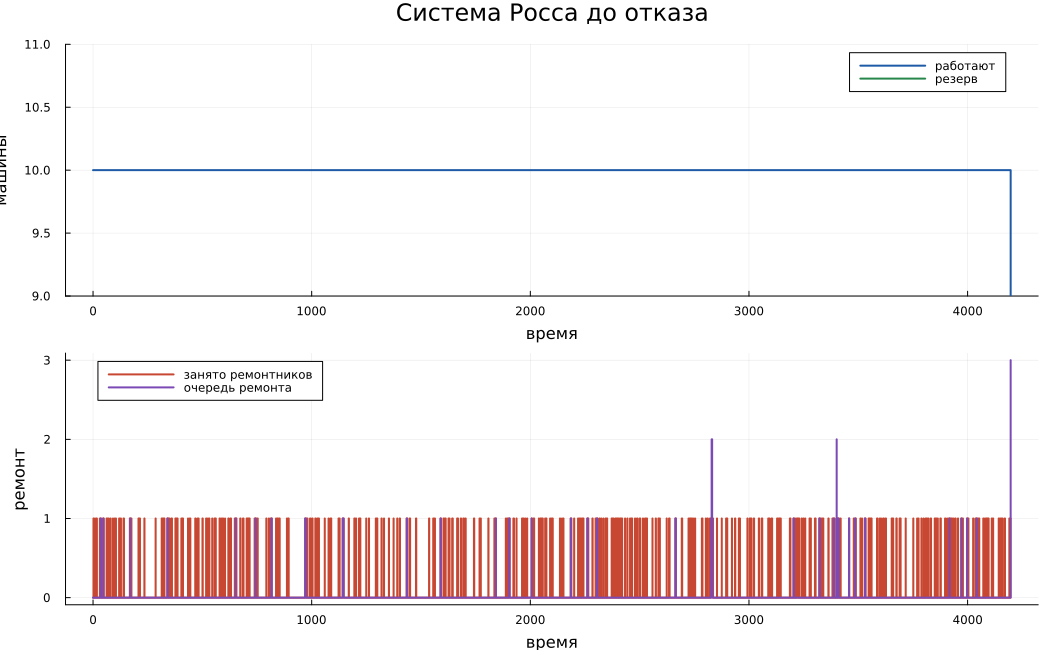

In [3]:
println(run_table[:, [:run, :failure_time, :utilization, :mean_queue, :transitions]])
println(comparison)
figure = reserve_trace_plot(first_trace, 10)
store_figure("reserve_baseline", "failure_path.png", figure)
figure

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*